In [1]:
!pip install torch==2.6.0 --quiet
!pip install matplotlib==3.10.1 --quiet
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

Однослойная параметры: 121
Двухслойная параметры: 118
Однослойная MSE = 0.00001299
Двухслойная MSE = 0.00000332


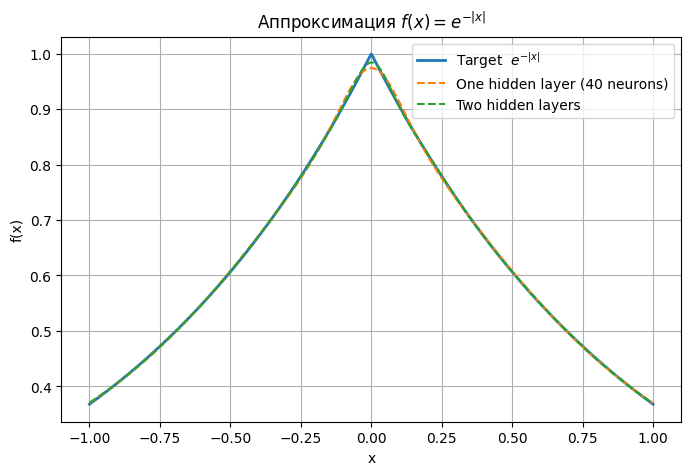

Однослойная параметры: 601
Двухслойная параметры: 118
Однослойная MSE = 0.00001517
Двухслойная MSE = 0.00000613


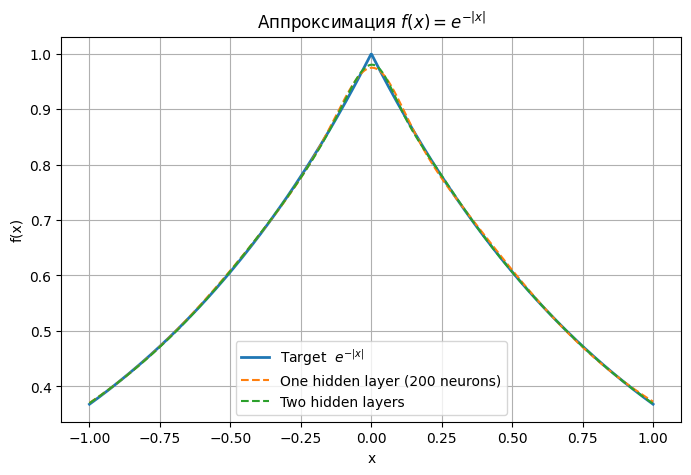

In [23]:
GLOBAL_SEED=6
torch.manual_seed(GLOBAL_SEED)

n_samples = 1000
X = torch.linspace(-1, 1, n_samples).unsqueeze(1)
y = torch.exp(-torch.abs(X))
for i in [40,200]:
    one_layer = nn.Sequential(
        nn.Linear(1, i),
        nn.Tanh(),
        nn.Linear(i, 1)
    )

    two_layer = nn.Sequential(
        nn.Linear(1, 9),
        nn.Tanh(),
        nn.Linear(9, 9),
        nn.Tanh(),
        nn.Linear(9, 1)
    )

    def count_params(model):
        return sum(p.numel() for p in model.parameters())

    print("Однослойная параметры:", count_params(one_layer))
    print("Двухслойная параметры:", count_params(two_layer))

    def train(model, X, y, epochs=6000, lr=0.01):
        optimizer = optim.Adam(model.parameters(), lr=lr)
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=300,
            min_lr=1e-5
        )
        loss_fn = nn.MSELoss()

        for _ in range(epochs):
            optimizer.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            optimizer.step()
            scheduler.step(loss)

        return loss.item()

    loss_one = train(one_layer, X, y)
    loss_two = train(two_layer, X, y)

    print(f"Однослойная MSE = {loss_one:.8f}")
    print(f"Двухслойная MSE = {loss_two:.8f}")

    with torch.no_grad():
        y_pred_one = one_layer(X)
        y_pred_two = two_layer(X)

    plt.figure(figsize=(8,5))
    plt.plot(X.numpy(), y.numpy(), label='Target  $e^{-|x|}$', linewidth=2)
    plt.plot(X.numpy(), y_pred_one.numpy(), '--', label=f'One hidden layer ({i} neurons)')
    plt.plot(X.numpy(), y_pred_two.numpy(), '--', label='Two hidden layers')
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Аппроксимация $f(x)=e^{-|x|}$")
    plt.grid(True)
    plt.show()